# 01 — Explore FoodSeg103 and scaffold the food-group mapping

Downloads FoodSeg103 via HuggingFace, prints dataset statistics, visualizes image/mask pairs, and writes the `assets/foodseg103_to_groups.csv` scaffold. The CSV is already filled — this notebook is primarily for reference and EDA.

## 1. Environment check

In [1]:
import sys, platform
import torch

print(f'Python  : {sys.version.split()[0]}')
print(f'Platform: {platform.platform()}')
print(f'Torch   : {torch.__version__}')
print(f'MPS avail : {torch.backends.mps.is_available()}')
print(f'MPS built : {torch.backends.mps.is_built()}')

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Python  : 3.12.2
Platform: macOS-26.3-arm64-arm-64bit
Torch   : 2.7.1
MPS avail : True
MPS built : True
Using device: mps


## 2. Load FoodSeg103

First run downloads ~500 MB into `~/.cache/huggingface/`.

In [2]:
from datasets import load_dataset

ds = load_dataset('EduardoPacheco/FoodSeg103')
print(ds)
print()
print(f"Train size     : {len(ds['train'])}")
print(f"Validation size: {len(ds['validation'])}")
print(f"Columns        : {ds['train'].column_names}")

sample = ds['train'][0]
print()
print(f"Sample image: {sample['image'].size}, mode={sample['image'].mode}")
print(f"Sample label: {sample['label'].size}, mode={sample['label'].mode}")
print(f"Classes on image: {sample['classes_on_image']}")

/Users/krishdembla/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating validation split: 100%|██████████| 2135/2135 [00:00<00:00, 23548.26 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'classes_on_image', 'id'],
        num_rows: 4983
    })
    validation: Dataset({
        features: ['image', 'label', 'classes_on_image', 'id'],
        num_rows: 2135
    })
})

Train size     : 4983
Validation size: 2135
Columns        : ['image', 'label', 'classes_on_image', 'id']

Sample image: (512, 384), mode=RGB
Sample label: (512, 384), mode=L
Classes on image: [0, 48, 66, 90]


## 3. Class names for FoodSeg103

From Wu et al., *A Large-Scale Benchmark for Food Image Segmentation* (ACM MM 2021).

In [3]:
FOODSEG103_CLASSES = [
    'background', 'candy', 'egg tart', 'french fries', 'chocolate', 'biscuit', 'popcorn',
    'pudding', 'ice cream', 'cheese butter', 'cake', 'wine', 'milkshake', 'coffee', 'juice',
    'milk', 'tea', 'almond', 'red beans', 'cashew', 'dried cranberries', 'soy', 'walnut',
    'peanut', 'egg', 'apple', 'date', 'apricot', 'avocado', 'banana', 'strawberry', 'cherry',
    'blueberry', 'raspberry', 'mango', 'olives', 'peach', 'lemon', 'pear', 'fig', 'pineapple',
    'grape', 'kiwi', 'melon', 'orange', 'watermelon', 'steak', 'pork', 'chicken duck',
    'sausage', 'fried meat', 'lamb', 'sauce', 'crab', 'fish', 'shellfish', 'shrimp', 'soup',
    'bread', 'corn', 'hamburg', 'pizza', 'hanamaki baozi', 'wonton dumplings', 'pasta',
    'noodles', 'rice', 'pie', 'tofu', 'eggplant', 'potato', 'garlic', 'cauliflower', 'tomato',
    'kelp', 'seaweed', 'spring onion', 'rape', 'ginger', 'okra', 'lettuce', 'pumpkin',
    'cucumber', 'white radish', 'carrot', 'asparagus', 'bamboo shoots', 'broccoli',
    'celery stick', 'cilantro mint', 'snow peas', 'cabbage', 'bean sprouts', 'onion',
    'pepper', 'green beans', 'French beans', 'king oyster mushroom', 'shiitake',
    'enoki mushroom', 'oyster mushroom', 'white button mushroom', 'salad', 'other ingredients',
]
assert len(FOODSEG103_CLASSES) == 104, f'Expected 104 (incl. background), got {len(FOODSEG103_CLASSES)}'
print(f'{len(FOODSEG103_CLASSES)} classes (including background at index 0).')
for i, c in enumerate(FOODSEG103_CLASSES):
    print(f'  {i:3d}  {c}')

104 classes (including background at index 0).
    0  background
    1  candy
    2  egg tart
    3  french fries
    4  chocolate
    5  biscuit
    6  popcorn
    7  pudding
    8  ice cream
    9  cheese butter
   10  cake
   11  wine
   12  milkshake
   13  coffee
   14  juice
   15  milk
   16  tea
   17  almond
   18  red beans
   19  cashew
   20  dried cranberries
   21  soy
   22  walnut
   23  peanut
   24  egg
   25  apple
   26  date
   27  apricot
   28  avocado
   29  banana
   30  strawberry
   31  cherry
   32  blueberry
   33  raspberry
   34  mango
   35  olives
   36  peach
   37  lemon
   38  pear
   39  fig
   40  pineapple
   41  grape
   42  kiwi
   43  melon
   44  orange
   45  watermelon
   46  steak
   47  pork
   48  chicken duck
   49  sausage
   50  fried meat
   51  lamb
   52  sauce
   53  crab
   54  fish
   55  shellfish
   56  shrimp
   57  soup
   58  bread
   59  corn
   60  hamburg
   61  pizza
   62  hanamaki baozi
   63  wonton dumplings
   64  p

## 4. Class-frequency histogram (train split)

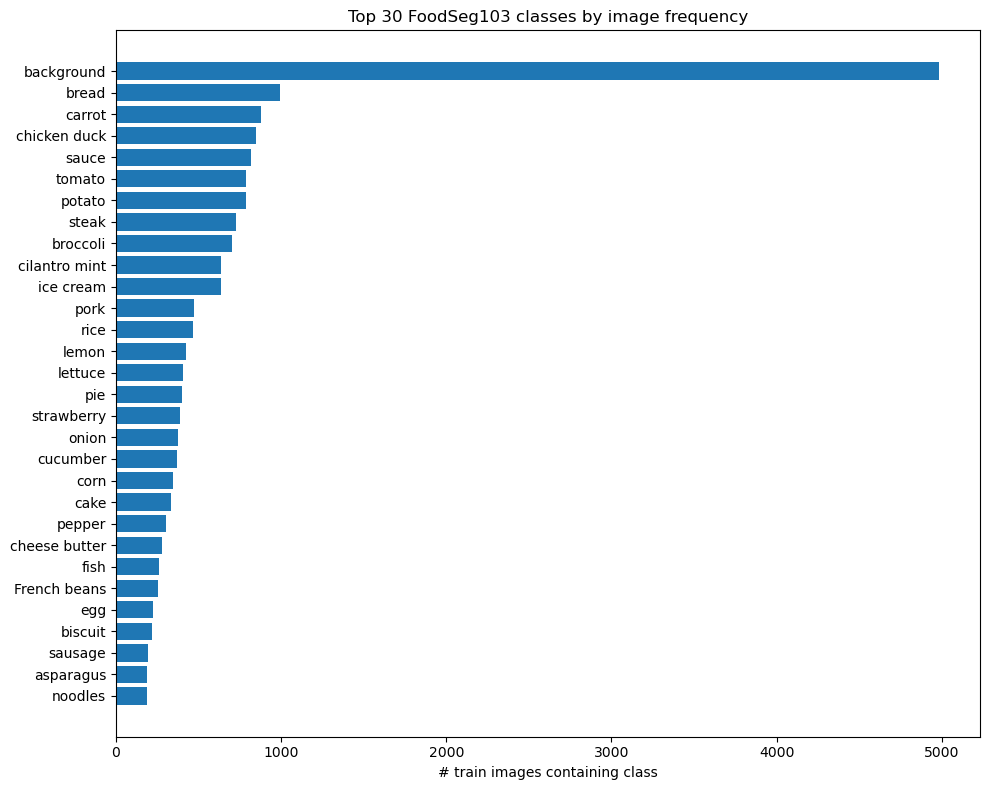

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

counter = Counter()
for ex in ds['train']:
    for c in ex['classes_on_image']:
        counter[int(c)] += 1

class_ids = list(range(len(FOODSEG103_CLASSES)))
counts    = [counter.get(c, 0) for c in class_ids]

order = np.argsort(counts)[::-1]
top_n = 30
top_ids = [class_ids[i] for i in order[:top_n]]
top_counts = [counts[i]  for i in order[:top_n]]
top_names  = [FOODSEG103_CLASSES[i] for i in top_ids]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top_counts[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel('# train images containing class')
ax.set_title(f'Top {top_n} FoodSeg103 classes by image frequency')
fig.tight_layout()
fig.savefig('../figures/class_frequency_top30.png', dpi=140)
plt.show()

## 5. Visualize sample image + mask pairs

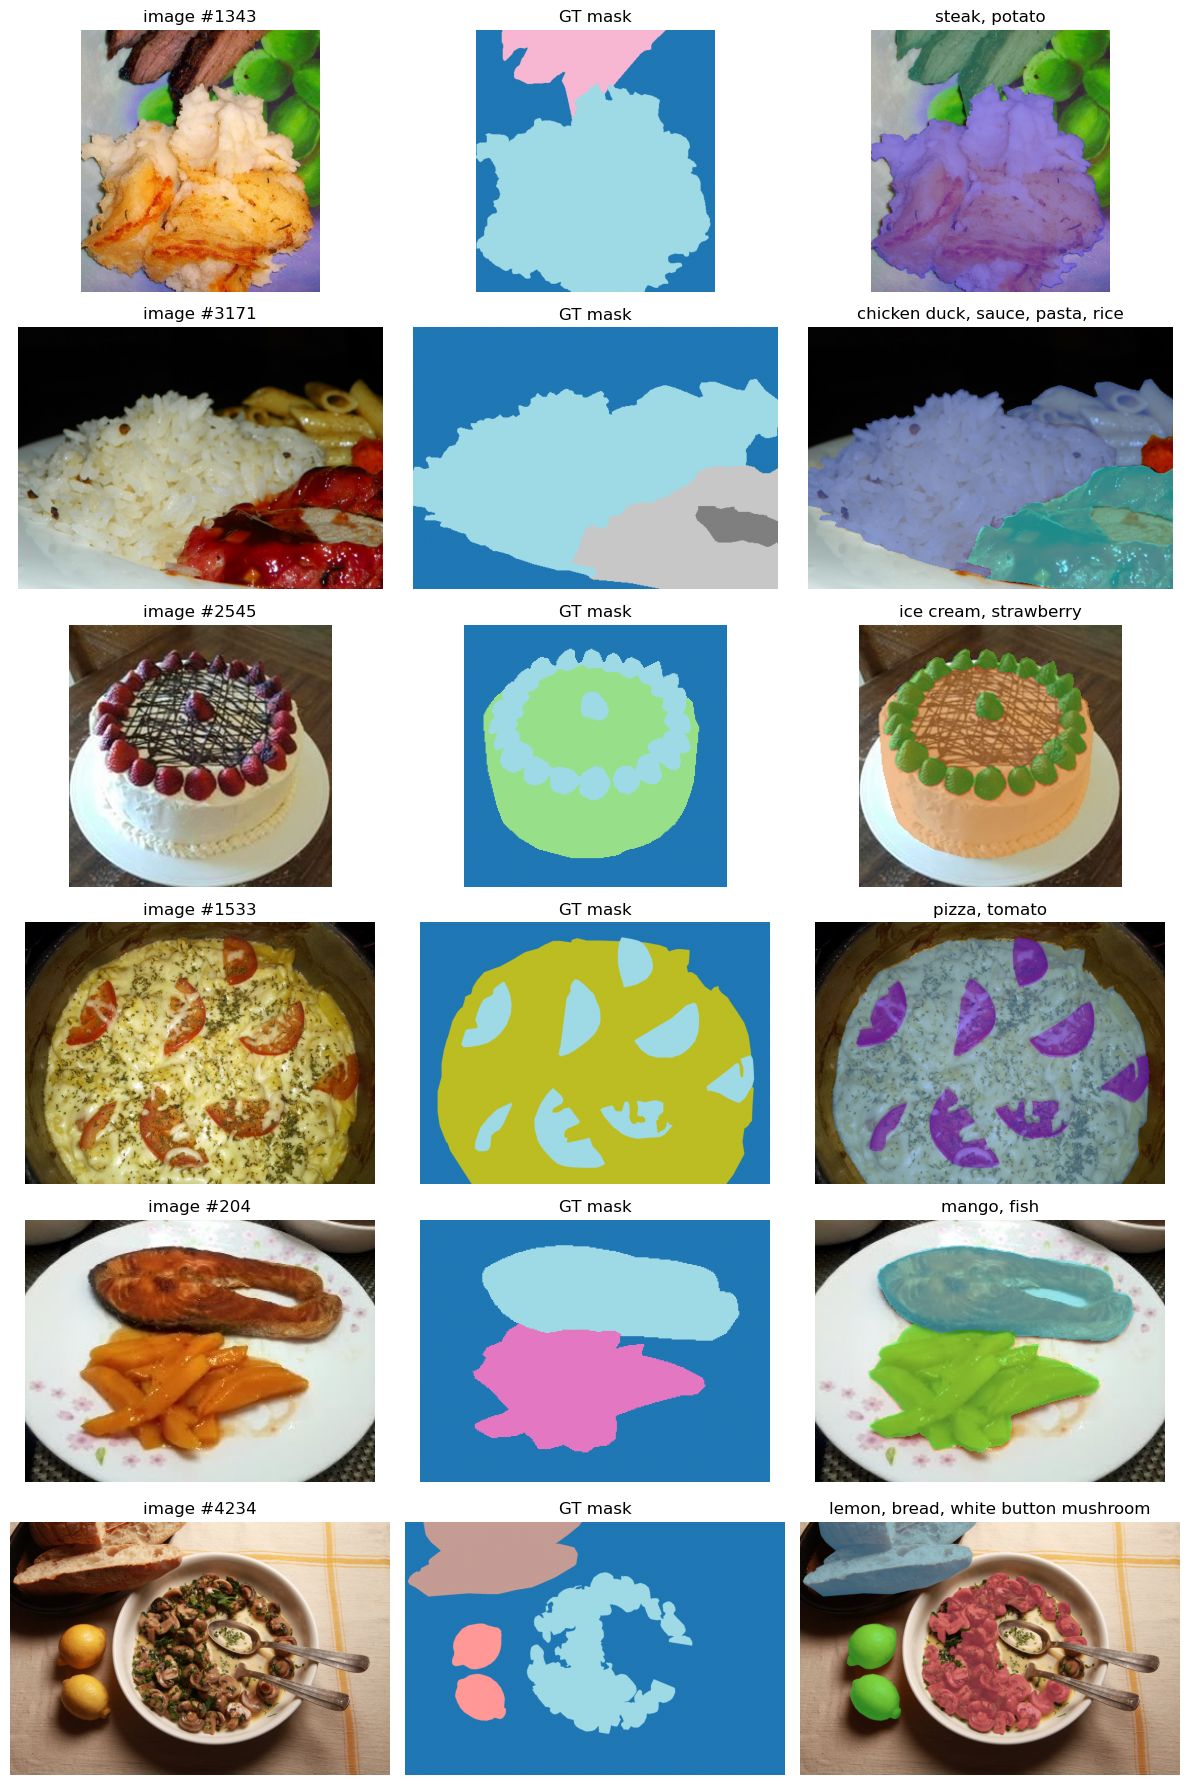

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from smartplate import overlay_mask

n_show = 6
rng = np.random.default_rng(0)
indices = rng.choice(len(ds['train']), size=n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3 * n_show))
for row, idx in enumerate(indices):
    ex = ds['train'][int(idx)]
    image = ex['image'].convert('RGB')
    mask  = np.array(ex['label'])
    present = sorted(set(mask.flatten().tolist()) - {0})
    names = [FOODSEG103_CLASSES[c] for c in present]

    axes[row, 0].imshow(image);      axes[row, 0].set_title(f'image #{idx}');   axes[row, 0].axis('off')
    axes[row, 1].imshow(mask, cmap='tab20'); axes[row, 1].set_title('GT mask');  axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay_mask(image, mask));  axes[row, 2].set_title(', '.join(names)[:60]); axes[row, 2].axis('off')

fig.tight_layout()
fig.savefig('../figures/sample_plates.png', dpi=140)
plt.show()

## 6. Scaffold `foodseg103_to_groups.csv`

Writes a CSV with one row per class and an empty `food_group` column. If the file already exists (as it does now) the cell is a no-op. The filled mapping is what drives `smartplate.score_plate`.

In [6]:
import csv
from pathlib import Path

csv_path = Path('../assets/foodseg103_to_groups.csv')

if csv_path.exists():
    print(f'{csv_path} already exists — leaving it alone. Edit it by hand.')
else:
    with open(csv_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['class_id', 'class_name', 'food_group'])
        for i, name in enumerate(FOODSEG103_CLASSES):
            default = 'background' if i == 0 else ''
            w.writerow([i, name, default])
    print(f'Wrote scaffold to {csv_path}. Now fill in the food_group column.')

Wrote scaffold to ../assets/foodseg103_to_groups.csv. Now fill in the food_group column.


## 7. Scaffold `usda_macros.csv`

Per-food-group reference macros (kcal / protein / carb / fat per 100 g) from USDA FoodData Central. Same no-op guard as above.

In [7]:
macros_path = Path('../assets/usda_macros.csv')
default_macros = [
    # group, kcal, protein_g, carb_g, fat_g  (per 100 g)
    ('vegetables',         35,  2,  7,  0.3),
    ('fruits',             60,  1, 15,  0.3),
    ('whole_grains',      340, 12, 65,  3.0),
    ('healthy_protein',   180, 22,  2,  9.0),
    ('refined_grains',    360,  8, 75,  2.0),
    ('red_processed_meat',290, 20,  1, 22.0),
    ('sugary_fatty',      450,  5, 55, 22.0),
]
if macros_path.exists():
    print(f'{macros_path} already exists — leaving it alone.')
else:
    with open(macros_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['food_group', 'kcal_per_100g', 'protein_g', 'carb_g', 'fat_g'])
        for row in default_macros:
            w.writerow(row)
    print(f'Wrote {macros_path}.')

Wrote ../assets/usda_macros.csv.
